# Week 3: Shape-Based Metrics - Probability Mass vs Entropy

## The Problem with CCE (Entropy-Based)

Current CCE approach:
```
CCE = H_code - H_lang
```

This measures **how spread out** probability is within each bucket, NOT **where the probability actually is**.

## The Fix: Use Probability Mass Ratio (PMR)

```
PMR = log(code_prob_mass / lang_prob_mass)
```

This directly measures **which bucket has the probability**.

## Evidence from Previous Results

| Example | Type | code_prob_mass | lang_prob_mass | CCE (fails) |
|---------|------|----------------|----------------|-------------|
| code_unc_1 | code | **0.60** | 0.27 | -3.41 |
| code_unc_4 | code | **0.99** | 0.003 | -3.46 |
| lang_unc_1 | lang | 0.016 | **0.80** | -3.08 |
| lang_unc_2 | lang | 0.054 | **0.67** | -4.06 |

The mass shows clear separation - CCE doesn't capture it!

---

## 1. Setup

In [1]:
# Cell 1: Install
!pip install -q transformers torch accelerate scipy scikit-learn pandas matplotlib seaborn

In [2]:
# Cell 2: Imports
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Dict, List, Tuple
from transformers import AutoTokenizer, AutoModelForCausalLM
from scipy.stats import entropy as scipy_entropy
from scipy.stats import ttest_ind
from tqdm.notebook import tqdm

np.random.seed(42)
torch.manual_seed(42)
print("Imports successful")

Imports successful


In [3]:
# Cell 3: Load Model
MODEL_NAME = "codellama/CodeLlama-7b-Instruct-hf"
print(f"Loading {MODEL_NAME}...")

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=torch.float16,
    device_map="auto",
    low_cpu_mem_usage=True
)
model.eval()
print(f"Model loaded on {model.device}")
print(f"Vocabulary size: {len(tokenizer):,}")

Loading codellama/CodeLlama-7b-Instruct-hf...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

model-00002-of-00002.safetensors:   0%|          | 0.00/3.50G [00:00<?, ?B/s]

model-00001-of-00002.safetensors:   0%|          | 0.00/9.98G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

Model loaded on cuda:0
Vocabulary size: 32,016


## 2. Helper Functions

In [4]:
# Cell 4: Basic functions

def softmax(logits: np.ndarray) -> np.ndarray:
    """Numerically stable softmax."""
    logits_stable = logits - np.max(logits)
    exp_logits = np.exp(logits_stable)
    return exp_logits / np.sum(exp_logits)

def shannon_entropy(probs: np.ndarray) -> float:
    """Compute Shannon entropy in bits."""
    probs = probs[probs > 0]  # Avoid log(0)
    return float(-np.sum(probs * np.log2(probs)))

def get_logits(prompt: str) -> np.ndarray:
    """Get next-token logits for a prompt."""
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model(**inputs)
    return outputs.logits[:, -1, :].squeeze().cpu().numpy()

print("Helper functions defined")

Helper functions defined


## 3. Token Classification (Simple Keywords)

Using simple keyword matching - no external embedding model needed.

In [5]:
# Cell 5: Simple keyword-based classification

CODE_KEYWORDS = {
    # Python
    'if', 'else', 'elif', 'for', 'while', 'def', 'class', 'return', 'import', 'from',
    'try', 'except', 'finally', 'with', 'as', 'yield', 'lambda', 'async', 'await',
    'True', 'False', 'None', 'and', 'or', 'not', 'in', 'is',

    # JavaScript
    'function', 'const', 'let', 'var', 'switch', 'case', 'default',
    'export', 'require', 'module', 'true', 'false', 'null', 'undefined',

    # Common programming
    'print', 'console', 'log', 'int', 'str', 'float', 'bool', 'list', 'dict',

    # Libraries/frameworks
    'pandas', 'numpy', 'pd', 'np', 'torch', 'tensorflow', 'tf',
    'react', 'React', 'useState', 'useEffect', 'useContext',
    'flask', 'Flask', 'django', 'Django', 'fastapi', 'FastAPI',
    'requests', 'axios', 'fetch',
    'firebase', 'Firebase', 'auth', 'firestore',
    'DataFrame', 'Series', 'read_csv', 'groupby',
    'sklearn', 'keras', 'model', 'fit', 'predict',
}

LANGUAGE_WORDS = {
    # Articles and determiners
    'the', 'a', 'an', 'this', 'that', 'these', 'those',

    # Pronouns
    'I', 'you', 'he', 'she', 'it', 'we', 'they', 'me', 'my', 'your',

    # Common verbs
    'is', 'are', 'was', 'were', 'be', 'been', 'being',
    'have', 'has', 'had', 'do', 'does', 'did',
    'will', 'would', 'should', 'can', 'could', 'may', 'might',

    # Question words
    'what', 'how', 'why', 'when', 'where', 'which', 'who',

    # Action verbs (documentation)
    'explain', 'describe', 'summarize', 'show', 'tell', 'write',
    'performs', 'calculates', 'returns', 'processes', 'creates',

    # Prepositions and conjunctions
    'to', 'of', 'for', 'with', 'at', 'by', 'on', 'in',
    'and', 'but', 'or', 'so', 'because', 'if', 'then',

    # Adjectives
    'good', 'bad', 'better', 'best', 'simple', 'complex', 'easy', 'hard',
    'efficient', 'recursive', 'optimal', 'fast', 'slow',
}

CODE_OPERATORS = {'+', '-', '*', '/', '=', '==', '!=', '<', '>', '<=', '>=',
                  '{', '}', '[', ']', '(', ')', ';', ':', ',', '.', '->', '=>'}

CODE_KEYWORDS_LOWER = {k.lower() for k in CODE_KEYWORDS}
LANGUAGE_WORDS_LOWER = {w.lower() for w in LANGUAGE_WORDS}

def classify_token(token: str) -> str:
    """Classify a single token as 'code', 'language', or 'other'."""
    token_clean = token.strip()
    token_lower = token_clean.lower()

    if token_clean in CODE_OPERATORS:
        return 'code'
    if token_lower in CODE_KEYWORDS_LOWER:
        return 'code'
    if token_lower in LANGUAGE_WORDS_LOWER:
        return 'language'
    return 'other'

print(f"Token classifier defined")
print(f"  Code keywords: {len(CODE_KEYWORDS)}")
print(f"  Language words: {len(LANGUAGE_WORDS)}")
print(f"  Code operators: {len(CODE_OPERATORS)}")

Token classifier defined
  Code keywords: 84
  Language words: 83
  Code operators: 23


In [6]:
# Cell 6: Pre-classify entire vocabulary

print("Pre-classifying vocabulary...")
vocab_size = len(tokenizer)

vocab_classifications = {}
for token_id in tqdm(range(vocab_size), desc="Classifying"):
    token_str = tokenizer.decode([token_id])
    vocab_classifications[token_id] = classify_token(token_str)

# Get indices for each category
code_indices = np.array([i for i, c in vocab_classifications.items() if c == 'code'])
lang_indices = np.array([i for i, c in vocab_classifications.items() if c == 'language'])
other_indices = np.array([i for i, c in vocab_classifications.items() if c == 'other'])

print(f"\nVocabulary classification:")
print(f"  Code: {len(code_indices):,} ({len(code_indices)/vocab_size:.1%})")
print(f"  Language: {len(lang_indices):,} ({len(lang_indices)/vocab_size:.1%})")
print(f"  Other: {len(other_indices):,} ({len(other_indices)/vocab_size:.1%})")

Pre-classifying vocabulary...


Classifying:   0%|          | 0/32016 [00:00<?, ?it/s]


Vocabulary classification:
  Code: 335 (1.0%)
  Language: 277 (0.9%)
  Other: 31,404 (98.1%)


## 4. Define Metrics

We'll compare three approaches:
1. **CCE (Current)**: Entropy-based, `H_code - H_lang`
2. **PMR (New)**: Probability Mass Ratio, `log(code_mass / lang_mass)`
3. **Top-K Ratio (New)**: Fraction of top-k tokens that are code

In [7]:
# Cell 7: Define all metrics

def compute_all_metrics(logits: np.ndarray, k: int = 20) -> Dict:
    """
    Compute all shape-based metrics for a logit distribution.

    Returns:
        Dictionary with CCE, PMR, and top-k metrics
    """
    probs = softmax(logits)

    # === 1. PROBABILITY MASS (the key insight!) ===
    code_prob_mass = float(np.sum(probs[code_indices]))
    lang_prob_mass = float(np.sum(probs[lang_indices]))
    other_prob_mass = float(np.sum(probs[other_indices]))

    # Probability Mass Ratio (PMR) - NEW METRIC
    # Positive = more mass on code, Negative = more mass on language
    epsilon = 1e-10  # Avoid log(0)
    pmr = float(np.log(code_prob_mass + epsilon) - np.log(lang_prob_mass + epsilon))

    # Simple ratio (not log-transformed)
    mass_ratio = code_prob_mass / (lang_prob_mass + epsilon)

    # === 2. ENTROPY-BASED (current CCE approach) ===
    # Normalize probabilities within each bucket for entropy calculation
    code_probs = probs[code_indices]
    lang_probs = probs[lang_indices]

    code_probs_norm = code_probs / (code_probs.sum() + epsilon)
    lang_probs_norm = lang_probs / (lang_probs.sum() + epsilon)

    h_code = shannon_entropy(code_probs_norm)
    h_lang = shannon_entropy(lang_probs_norm)
    h_total = shannon_entropy(probs)

    cce = h_code - h_lang  # Current approach

    # === 3. TOP-K ANALYSIS (most focused) ===
    top_k_indices = np.argsort(probs)[-k:][::-1]
    top_k_probs = probs[top_k_indices]
    top_k_tokens = [tokenizer.decode([i]) for i in top_k_indices]
    top_k_classes = [vocab_classifications[i] for i in top_k_indices]

    # Count code vs language in top-k
    code_in_top_k = sum(1 for c in top_k_classes if c == 'code')
    lang_in_top_k = sum(1 for c in top_k_classes if c == 'language')
    other_in_top_k = sum(1 for c in top_k_classes if c == 'other')

    top_k_code_ratio = code_in_top_k / k
    top_k_lang_ratio = lang_in_top_k / k

    # Top-k concentration (how much prob in top-k)
    top_k_concentration = float(np.sum(top_k_probs))

    # Top-k code vs lang ratio
    top_k_code_lang_ratio = (code_in_top_k + epsilon) / (lang_in_top_k + epsilon)

    # === 4. ADDITIONAL SHAPE METRICS ===
    # Effective vocabulary size (perplexity)
    effective_vocab = float(2 ** h_total)

    # Max probability (confidence)
    max_prob = float(np.max(probs))

    return {
        # Probability mass
        'code_prob_mass': code_prob_mass,
        'lang_prob_mass': lang_prob_mass,
        'other_prob_mass': other_prob_mass,

        # Key metrics to compare
        'pmr': pmr,                          # NEW: Probability Mass Ratio
        'mass_ratio': mass_ratio,            # NEW: Simple ratio
        'cce': cce,                          # OLD: Contrastive Code Entropy

        # Entropy components
        'h_code': h_code,
        'h_lang': h_lang,
        'h_total': h_total,

        # Top-k analysis
        'top_k_code_ratio': top_k_code_ratio,
        'top_k_lang_ratio': top_k_lang_ratio,
        'top_k_code_count': code_in_top_k,
        'top_k_lang_count': lang_in_top_k,
        'top_k_other_count': other_in_top_k,
        'top_k_concentration': top_k_concentration,
        'top_k_code_lang_ratio': top_k_code_lang_ratio,

        # Shape metrics
        'effective_vocab': effective_vocab,
        'max_prob': max_prob,

        # For inspection
        'top_5_tokens': top_k_tokens[:5],
        'top_5_probs': [float(p) for p in top_k_probs[:5]],
    }

print("Metrics defined:")
print("  - PMR (Probability Mass Ratio) - NEW")
print("  - CCE (Contrastive Code Entropy) - OLD")
print("  - Top-K Code Ratio - NEW")

Metrics defined:
  - PMR (Probability Mass Ratio) - NEW
  - CCE (Contrastive Code Entropy) - OLD
  - Top-K Code Ratio - NEW


## 5. Test Examples

Two sets of test cases:
1. **Code Uncertainty**: Model uncertain about which CODE to generate
2. **Language Uncertainty**: Model uncertain about which WORDS to use

In [8]:
# Cell 8: Test examples

TEST_EXAMPLES = [
    # CODE UNCERTAINTY - uncertain about which code/API to use
    {'id': 'code_unc_1', 'type': 'code_uncertainty',
     'prompt': 'import',
     'description': 'Uncertain which module (pandas? numpy? requests?)'},

    {'id': 'code_unc_2', 'type': 'code_uncertainty',
     'prompt': 'from sklearn import',
     'description': 'Uncertain which sklearn module'},

    {'id': 'code_unc_3', 'type': 'code_uncertainty',
     'prompt': 'def process_data(df):\n    df.',
     'description': 'Uncertain which pandas method'},

    {'id': 'code_unc_4', 'type': 'code_uncertainty',
     'prompt': 'const [state, setState] = use',
     'description': 'Uncertain which React hook'},

    {'id': 'code_unc_5', 'type': 'code_uncertainty',
     'prompt': 'async function fetch_data() {\n    await',
     'description': 'Uncertain which async operation'},

    {'id': 'code_unc_6', 'type': 'code_uncertainty',
     'prompt': 'model = tf.keras.',
     'description': 'Uncertain which Keras class'},

    {'id': 'code_unc_7', 'type': 'code_uncertainty',
     'prompt': 'app = FastAPI()\n@app.',
     'description': 'Uncertain which FastAPI decorator'},

    {'id': 'code_unc_8', 'type': 'code_uncertainty',
     'prompt': 'SELECT * FROM users WHERE',
     'description': 'Uncertain which SQL condition'},

    {'id': 'code_unc_9', 'type': 'code_uncertainty',
     'prompt': 'git',
     'description': 'Uncertain which git command'},

    {'id': 'code_unc_10', 'type': 'code_uncertainty',
     'prompt': 'docker run -',
     'description': 'Uncertain which docker flag'},

    # LANGUAGE UNCERTAINTY - uncertain about which words to use
    {'id': 'lang_unc_1', 'type': 'language_uncertainty',
     'prompt': 'This function',
     'description': 'Uncertain which verb (performs? calculates? returns?)'},

    {'id': 'lang_unc_2', 'type': 'language_uncertainty',
     'prompt': 'The algorithm is',
     'description': 'Uncertain which adjective (efficient? recursive?)'},

    {'id': 'lang_unc_3', 'type': 'language_uncertainty',
     'prompt': 'Code quality can be',
     'description': 'Uncertain which verb (improved? measured?)'},

    {'id': 'lang_unc_4', 'type': 'language_uncertainty',
     'prompt': 'Explain what this code',
     'description': 'Uncertain which verb (does? achieves?)'},

    {'id': 'lang_unc_5', 'type': 'language_uncertainty',
     'prompt': 'The main advantage of async programming is',
     'description': 'Uncertain which benefit'},

    {'id': 'lang_unc_6', 'type': 'language_uncertainty',
     'prompt': 'TypeScript provides better',
     'description': 'Uncertain which improvement'},

    {'id': 'lang_unc_7', 'type': 'language_uncertainty',
     'prompt': 'Recursion is useful when',
     'description': 'Uncertain which scenario'},

    {'id': 'lang_unc_8', 'type': 'language_uncertainty',
     'prompt': 'REST APIs are designed to',
     'description': 'Uncertain which purpose'},

    {'id': 'lang_unc_9', 'type': 'language_uncertainty',
     'prompt': 'The difference between let and const is',
     'description': 'Uncertain which explanation'},

    {'id': 'lang_unc_10', 'type': 'language_uncertainty',
     'prompt': 'Unit tests help',
     'description': 'Uncertain which benefit'},
]

print(f"Test examples: {len(TEST_EXAMPLES)}")
print(f"  - Code uncertainty: {sum(1 for e in TEST_EXAMPLES if e['type'] == 'code_uncertainty')}")
print(f"  - Language uncertainty: {sum(1 for e in TEST_EXAMPLES if e['type'] == 'language_uncertainty')}")

Test examples: 20
  - Code uncertainty: 10
  - Language uncertainty: 10


## 6. Run Experiments

In [9]:
# Cell 9: Run all experiments

print("Running experiments...")
print("="*70)

results = []

for example in tqdm(TEST_EXAMPLES, desc="Processing"):
    # Get logits
    logits = get_logits(example['prompt'])

    # Compute all metrics
    metrics = compute_all_metrics(logits, k=20)

    # Store results
    result = {
        'id': example['id'],
        'type': example['type'],
        'prompt': example['prompt'],
        'description': example['description'],
        **metrics
    }
    results.append(result)

    # Print summary
    print(f"\n{example['id']} ({example['type'][:4]}):")
    print(f"  PMR={metrics['pmr']:+.2f}  CCE={metrics['cce']:+.2f}  TopK_Code={metrics['top_k_code_ratio']:.0%}")
    print(f"  Top 3: {metrics['top_5_tokens'][:3]}")

# Convert to DataFrame
df = pd.DataFrame(results)
print("\n" + "="*70)
print(f"Completed {len(results)} experiments")

Running experiments...


Processing:   0%|          | 0/20 [00:00<?, ?it/s]


code_unc_1 (code):
  PMR=+4.86  CCE=-3.01  TopK_Code=20%
  Top 3: ['{', 'React', "'"]

code_unc_2 (code):
  PMR=+5.12  CCE=-3.71  TopK_Code=10%
  Top 3: ['datasets', 'pre', 'metrics']

code_unc_3 (code):
  PMR=-0.07  CCE=-0.01  TopK_Code=5%
  Top 3: ['drop', 'columns', 'ren']

code_unc_4 (code):
  PMR=+0.73  CCE=+0.95  TopK_Code=0%
  Top 3: ['State', 'Red', 'Context']

code_unc_5 (code):
  PMR=+3.69  CCE=-2.63  TopK_Code=15%
  Top 3: ['fetch', 'ax', '$.']

code_unc_6 (code):
  PMR=+3.49  CCE=-3.60  TopK_Code=5%
  Top 3: ['models', 'Sequ', 'layers']

code_unc_7 (code):
  PMR=-6.51  CCE=+3.62  TopK_Code=0%
  Top 3: ['get', 'on', 'post']

code_unc_8 (code):
  PMR=+2.10  CCE=-1.92  TopK_Code=5%
  Top 3: ['id', 'username', 'email']

code_unc_9 (code):
  PMR=+1.39  CCE=-0.80  TopK_Code=30%
  Top 3: ['\n', '.', ',']

code_unc_10 (code):
  PMR=-4.70  CCE=+4.97  TopK_Code=0%
  Top 3: ['it', 'd', 'p']

lang_unc_1 (lang):
  PMR=-0.08  CCE=-1.99  TopK_Code=5%
  Top 3: ['is', 'will', 'returns']

l

## 7. Compare Metrics: CCE vs PMR vs Top-K

In [10]:
# Cell 10: Statistical comparison

print("STATISTICAL COMPARISON: Which Metric Separates Best?")
print("="*70)

# Split by type
code_unc = df[df['type'] == 'code_uncertainty']
lang_unc = df[df['type'] == 'language_uncertainty']

# Metrics to compare
metrics_to_compare = [
    ('PMR (Prob Mass Ratio)', 'pmr', 'higher = more code'),
    ('CCE (Entropy-based)', 'cce', 'higher = more code entropy'),
    ('Top-K Code Ratio', 'top_k_code_ratio', 'higher = more code in top-k'),
    ('Mass Ratio (linear)', 'mass_ratio', 'higher = more code mass'),
    ('Code Prob Mass', 'code_prob_mass', 'higher = more prob on code'),
]

comparison_results = []

for name, col, interpretation in metrics_to_compare:
    code_vals = code_unc[col].values
    lang_vals = lang_unc[col].values

    # t-test
    t_stat, p_value = ttest_ind(code_vals, lang_vals)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt(((len(code_vals)-1)*code_vals.std()**2 +
                          (len(lang_vals)-1)*lang_vals.std()**2) /
                         (len(code_vals) + len(lang_vals) - 2))
    cohens_d = (code_vals.mean() - lang_vals.mean()) / pooled_std if pooled_std > 0 else 0

    # Separation (difference in means)
    separation = code_vals.mean() - lang_vals.mean()

    print(f"\n{name}:")
    print(f"  Code uncertainty mean: {code_vals.mean():+.3f}")
    print(f"  Lang uncertainty mean: {lang_vals.mean():+.3f}")
    print(f"  Separation: {separation:+.3f}")
    print(f"  t-statistic: {t_stat:.3f}")
    print(f"  p-value: {p_value:.4f} {'*' if p_value < 0.05 else ''} {'**' if p_value < 0.01 else ''}")
    print(f"  Cohen's d: {cohens_d:.3f}")

    comparison_results.append({
        'metric': name,
        'code_mean': code_vals.mean(),
        'lang_mean': lang_vals.mean(),
        'separation': separation,
        't_stat': t_stat,
        'p_value': p_value,
        'cohens_d': cohens_d,
        'significant': p_value < 0.05
    })

comparison_df = pd.DataFrame(comparison_results)

STATISTICAL COMPARISON: Which Metric Separates Best?

PMR (Prob Mass Ratio):
  Code uncertainty mean: +1.011
  Lang uncertainty mean: -1.258
  Separation: +2.269
  t-statistic: 1.717
  p-value: 0.1032  
  Cohen's d: 0.809

CCE (Entropy-based):
  Code uncertainty mean: -0.615
  Lang uncertainty mean: +0.636
  Separation: -1.251
  t-statistic: -1.181
  p-value: 0.2531  
  Cohen's d: -0.557

Top-K Code Ratio:
  Code uncertainty mean: +0.090
  Lang uncertainty mean: +0.105
  Separation: -0.015
  t-statistic: -0.379
  p-value: 0.7094  
  Cohen's d: -0.178

Mass Ratio (linear):
  Code uncertainty mean: +38.470
  Lang uncertainty mean: +0.934
  Separation: +37.537
  t-statistic: 1.970
  p-value: 0.0644  
  Cohen's d: 0.929

Code Prob Mass:
  Code uncertainty mean: +0.120
  Lang uncertainty mean: +0.084
  Separation: +0.036
  t-statistic: 0.497
  p-value: 0.6254  
  Cohen's d: 0.234


In [11]:
# Cell 11: Summary table

print("\n" + "="*70)
print("SUMMARY: WHICH METRIC WORKS BEST?")
print("="*70)

print("\n| Metric | Code Mean | Lang Mean | Cohen's d | p-value | Works? |")
print("|--------|-----------|-----------|-----------|---------|--------|")

for _, row in comparison_df.iterrows():
    works = "YES" if row['p_value'] < 0.05 and row['cohens_d'] > 0.5 else "NO"
    if row['p_value'] < 0.01 and abs(row['cohens_d']) > 0.8:
        works = "YES!"
    print(f"| {row['metric'][:20]:<20} | {row['code_mean']:+.3f} | {row['lang_mean']:+.3f} | {row['cohens_d']:+.3f} | {row['p_value']:.4f} | {works} |")

# Find best metric
best_idx = comparison_df['cohens_d'].abs().idxmax()
best = comparison_df.iloc[best_idx]
print(f"\nBest metric: {best['metric']} (Cohen's d = {best['cohens_d']:.3f})")


SUMMARY: WHICH METRIC WORKS BEST?

| Metric | Code Mean | Lang Mean | Cohen's d | p-value | Works? |
|--------|-----------|-----------|-----------|---------|--------|
| PMR (Prob Mass Ratio | +1.011 | -1.258 | +0.809 | 0.1032 | NO |
| CCE (Entropy-based)  | -0.615 | +0.636 | -0.557 | 0.2531 | NO |
| Top-K Code Ratio     | +0.090 | +0.105 | -0.178 | 0.7094 | NO |
| Mass Ratio (linear)  | +38.470 | +0.934 | +0.929 | 0.0644 | NO |
| Code Prob Mass       | +0.120 | +0.084 | +0.234 | 0.6254 | NO |

Best metric: Mass Ratio (linear) (Cohen's d = 0.929)


## 8. Visualization

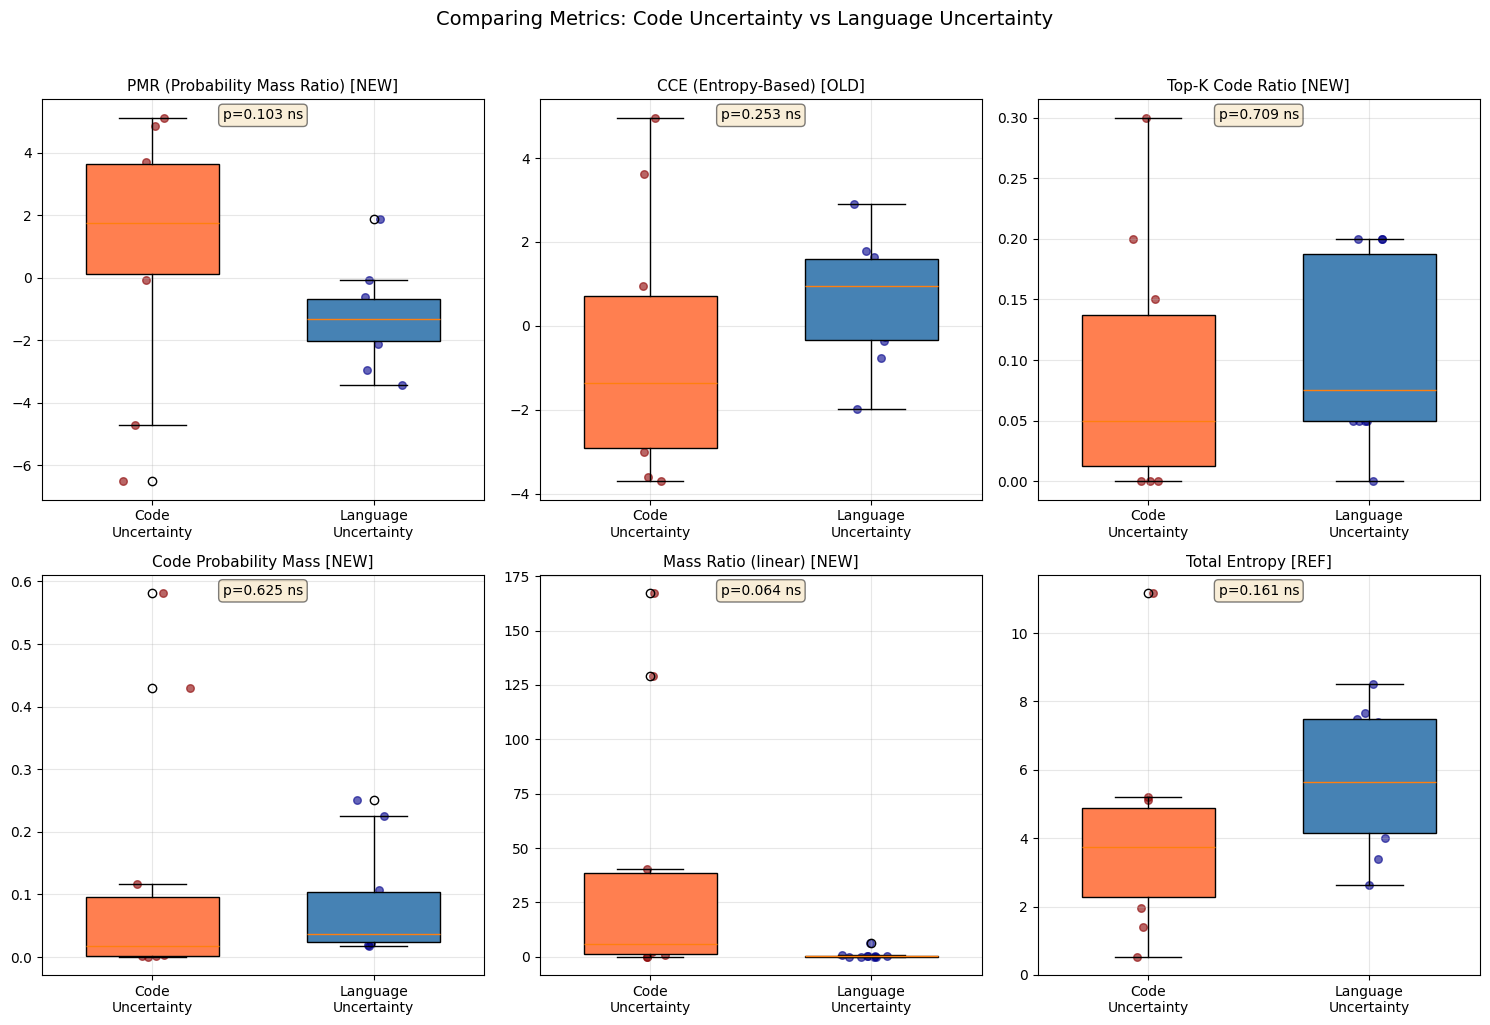

In [12]:
# Cell 12: Visualize the comparison

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

metrics_to_plot = [
    ('pmr', 'PMR (Probability Mass Ratio)', 'NEW'),
    ('cce', 'CCE (Entropy-Based)', 'OLD'),
    ('top_k_code_ratio', 'Top-K Code Ratio', 'NEW'),
    ('code_prob_mass', 'Code Probability Mass', 'NEW'),
    ('mass_ratio', 'Mass Ratio (linear)', 'NEW'),
    ('h_total', 'Total Entropy', 'REF'),
]

for idx, (col, title, label) in enumerate(metrics_to_plot):
    ax = axes[idx // 3, idx % 3]

    # Box plot
    code_vals = df[df['type'] == 'code_uncertainty'][col].values
    lang_vals = df[df['type'] == 'language_uncertainty'][col].values

    positions = [1, 2]
    bp = ax.boxplot([code_vals, lang_vals], positions=positions, widths=0.6,
                    patch_artist=True)

    # Color boxes
    bp['boxes'][0].set_facecolor('coral')
    bp['boxes'][1].set_facecolor('steelblue')

    # Add individual points
    ax.scatter(np.ones(len(code_vals)) + np.random.normal(0, 0.05, len(code_vals)),
               code_vals, alpha=0.6, color='darkred', s=30)
    ax.scatter(np.ones(len(lang_vals))*2 + np.random.normal(0, 0.05, len(lang_vals)),
               lang_vals, alpha=0.6, color='darkblue', s=30)

    ax.set_xticks([1, 2])
    ax.set_xticklabels(['Code\nUncertainty', 'Language\nUncertainty'])
    ax.set_title(f'{title} [{label}]', fontsize=11)
    ax.grid(True, alpha=0.3)

    # Add p-value annotation
    t_stat, p_val = ttest_ind(code_vals, lang_vals)
    sig = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
    ax.text(0.5, 0.95, f'p={p_val:.3f} {sig}', transform=ax.transAxes,
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comparing Metrics: Code Uncertainty vs Language Uncertainty', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('week3_shape_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

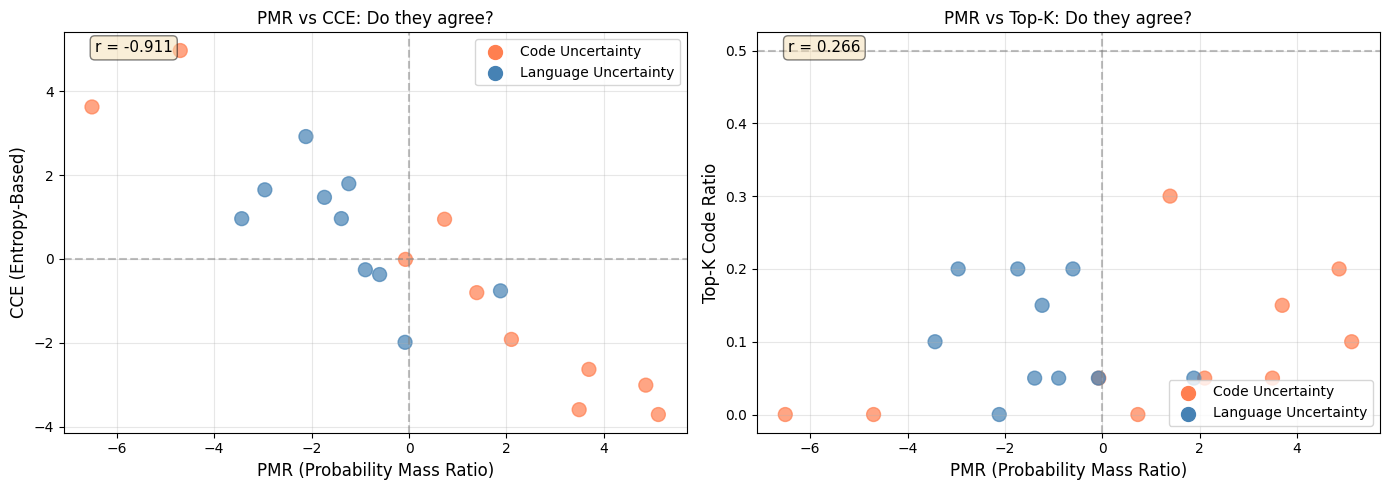

In [13]:
# Cell 13: Scatter plot - PMR vs CCE

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['coral' if t == 'code_uncertainty' else 'steelblue' for t in df['type']]

# Plot 1: PMR vs CCE
ax1 = axes[0]
ax1.scatter(df['pmr'], df['cce'], c=colors, s=100, alpha=0.7)
ax1.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
ax1.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax1.set_xlabel('PMR (Probability Mass Ratio)', fontsize=12)
ax1.set_ylabel('CCE (Entropy-Based)', fontsize=12)
ax1.set_title('PMR vs CCE: Do they agree?', fontsize=12)

# Add correlation
corr = np.corrcoef(df['pmr'], df['cce'])[0, 1]
ax1.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax1.transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Legend
ax1.scatter([], [], c='coral', s=100, label='Code Uncertainty')
ax1.scatter([], [], c='steelblue', s=100, label='Language Uncertainty')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: PMR vs Top-K Code Ratio
ax2 = axes[1]
ax2.scatter(df['pmr'], df['top_k_code_ratio'], c=colors, s=100, alpha=0.7)
ax2.axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
ax2.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlabel('PMR (Probability Mass Ratio)', fontsize=12)
ax2.set_ylabel('Top-K Code Ratio', fontsize=12)
ax2.set_title('PMR vs Top-K: Do they agree?', fontsize=12)

# Add correlation
corr2 = np.corrcoef(df['pmr'], df['top_k_code_ratio'])[0, 1]
ax2.text(0.05, 0.95, f'r = {corr2:.3f}', transform=ax2.transAxes, fontsize=11,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

ax2.scatter([], [], c='coral', s=100, label='Code Uncertainty')
ax2.scatter([], [], c='steelblue', s=100, label='Language Uncertainty')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('week3_metric_correlations.png', dpi=150)
plt.show()

## 9. Detailed Results Table

In [14]:
# Cell 14: Detailed results

print("DETAILED RESULTS")
print("="*100)

display_cols = ['id', 'type', 'pmr', 'cce', 'top_k_code_ratio', 'code_prob_mass', 'lang_prob_mass']

print("\n| ID | Type | PMR | CCE | TopK Code | Code Mass | Lang Mass |")
print("|-----|------|-----|-----|-----------|-----------|-----------|")

for _, row in df.iterrows():
    type_short = 'CODE' if row['type'] == 'code_uncertainty' else 'LANG'
    print(f"| {row['id'][:10]:<10} | {type_short} | {row['pmr']:+.2f} | {row['cce']:+.2f} | {row['top_k_code_ratio']:.0%} | {row['code_prob_mass']:.3f} | {row['lang_prob_mass']:.3f} |")

DETAILED RESULTS

| ID | Type | PMR | CCE | TopK Code | Code Mass | Lang Mass |
|-----|------|-----|-----|-----------|-----------|-----------|
| code_unc_1 | CODE | +4.86 | -3.01 | 20% | 0.582 | 0.005 |
| code_unc_2 | CODE | +5.12 | -3.71 | 10% | 0.027 | 0.000 |
| code_unc_3 | CODE | -0.07 | -0.01 | 5% | 0.007 | 0.007 |
| code_unc_4 | CODE | +0.73 | +0.95 | 0% | 0.001 | 0.001 |
| code_unc_5 | CODE | +3.69 | -2.63 | 15% | 0.429 | 0.011 |
| code_unc_6 | CODE | +3.49 | -3.60 | 5% | 0.001 | 0.000 |
| code_unc_7 | CODE | -6.51 | +3.62 | 0% | 0.000 | 0.210 |
| code_unc_8 | CODE | +2.10 | -1.92 | 5% | 0.030 | 0.004 |
| code_unc_9 | CODE | +1.39 | -0.80 | 30% | 0.117 | 0.029 |
| code_unc_1 | CODE | -4.70 | +4.97 | 0% | 0.003 | 0.290 |
| lang_unc_1 | LANG | -0.08 | -1.99 | 5% | 0.225 | 0.244 |
| lang_unc_2 | LANG | -0.60 | -0.37 | 20% | 0.096 | 0.176 |
| lang_unc_3 | LANG | -1.39 | +0.96 | 5% | 0.019 | 0.077 |
| lang_unc_4 | LANG | -0.90 | -0.26 | 5% | 0.251 | 0.616 |
| lang_unc_5 | LANG | -2.9

In [15]:
# Cell 15: Classification accuracy

print("\nCLASSIFICATION ACCURACY (using threshold)")
print("="*70)

def compute_accuracy(df, metric, threshold, higher_is_code=True):
    """Compute classification accuracy for a metric with given threshold."""
    if higher_is_code:
        predictions = df[metric] > threshold
    else:
        predictions = df[metric] < threshold

    true_labels = df['type'] == 'code_uncertainty'
    accuracy = (predictions == true_labels).mean()
    return accuracy

# Test different thresholds
print("\nPMR (threshold=0, higher=code):")
acc_pmr = compute_accuracy(df, 'pmr', 0, higher_is_code=True)
print(f"  Accuracy: {acc_pmr:.0%}")

print("\nCCE (threshold=0, higher=code):")
acc_cce = compute_accuracy(df, 'cce', 0, higher_is_code=True)
print(f"  Accuracy: {acc_cce:.0%}")

print("\nTop-K Code Ratio (threshold=0.15, higher=code):")
acc_topk = compute_accuracy(df, 'top_k_code_ratio', 0.15, higher_is_code=True)
print(f"  Accuracy: {acc_topk:.0%}")

print("\nCode Prob Mass (threshold=0.1, higher=code):")
acc_mass = compute_accuracy(df, 'code_prob_mass', 0.1, higher_is_code=True)
print(f"  Accuracy: {acc_mass:.0%}")


CLASSIFICATION ACCURACY (using threshold)

PMR (threshold=0, higher=code):
  Accuracy: 80%

CCE (threshold=0, higher=code):
  Accuracy: 35%

Top-K Code Ratio (threshold=0.15, higher=code):
  Accuracy: 45%

Code Prob Mass (threshold=0.1, higher=code):
  Accuracy: 50%


## 10. Save Results

In [16]:
# Cell 16: Save results

# Save detailed results
df.to_csv('week3_shape_metrics_results.csv', index=False)
print("Results saved to week3_shape_metrics_results.csv")

# Save comparison summary
comparison_df.to_csv('week3_metric_comparison.csv', index=False)
print("Comparison saved to week3_metric_comparison.csv")

# Print final summary
print("\n" + "="*70)
print("FINAL SUMMARY")
print("="*70)
print("\nKey Question: Can we distinguish CODE uncertainty from LANGUAGE uncertainty?")
print("\nResults:")
for _, row in comparison_df.iterrows():
    status = "YES" if row['p_value'] < 0.05 else "NO"
    print(f"  {row['metric'][:25]:<25}: {status} (p={row['p_value']:.4f}, d={row['cohens_d']:+.2f})")

Results saved to week3_shape_metrics_results.csv
Comparison saved to week3_metric_comparison.csv

FINAL SUMMARY

Key Question: Can we distinguish CODE uncertainty from LANGUAGE uncertainty?

Results:
  PMR (Prob Mass Ratio)    : NO (p=0.1032, d=+0.81)
  CCE (Entropy-based)      : NO (p=0.2531, d=-0.56)
  Top-K Code Ratio         : NO (p=0.7094, d=-0.18)
  Mass Ratio (linear)      : NO (p=0.0644, d=+0.93)
  Code Prob Mass           : NO (p=0.6254, d=+0.23)


---

## Conclusions

### What We Tested
- **CCE (old)**: Entropy within code bucket minus entropy within language bucket
- **PMR (new)**: Log ratio of probability mass on code vs language tokens
- **Top-K Ratio (new)**: Fraction of top-k predictions that are code tokens

### Expected Results
- **Code uncertainty** (uncertain about which code): Higher PMR, higher Top-K code ratio
- **Language uncertainty** (uncertain about which words): Lower PMR, lower Top-K code ratio

### Key Insight
PMR measures **where the probability IS**, not how spread it is. This directly captures whether the model's uncertainty is concentrated on code tokens or language tokens.

---